# 🏟️ Análise do Circuito

Antes de entrarmos em detalhes acerca das informações específicas deste final de semana, que tal observarmos os dados históricos desse GP?

Por estarmos tentando manter segredo de onde esse evento está acontecendo, muitos dados dessa análise estarão ocultos e limitados.

Nota: para simplificarmos a análise, vamos considerar que temos as mesmas condições de clima ao longo das sessões, isso é, essa análise não envolverá chuva.

## ⚙️ Configurações de ambiente

In [1]:
import os

import fastf1 as ff1
from dotenv import load_dotenv
from fastf1 import plotting
from fastf1.logger import set_log_level

from plots.laps import (
    plot_laptime_correlation_heatmap,
    plot_position_correlation_heatmap,
)
from processing.incidents import get_all_incidents_data

load_dotenv()

set_log_level("ERROR")
ff1.Cache.enable_cache("cache")
plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")

TEAM = os.getenv("TEAM")
EVENT_YEAR = int(os.getenv("EVENT_YEAR"))
GP_NAME = os.getenv("GP_NAME")

%matplotlib widget

## 📚 Agregando e limpando dados

### ⛏️ Extraindo dados

In [2]:
race_2021 = ff1.get_session(EVENT_YEAR - 4, GP_NAME, "R")
# In 2022, the GP did not happen.
race_2023 = ff1.get_session(EVENT_YEAR - 2, GP_NAME, "R")
last_year_race = ff1.get_session(EVENT_YEAR - 1, GP_NAME, "R")

In [3]:
race_2021.load(telemetry=False, weather=False)
race_2023.load(telemetry=False, weather=False)
last_year_race.load(telemetry=False, weather=False)

### 📚 Agregando dados

In [4]:
incidents = get_all_incidents_data([race_2021, race_2023, last_year_race])

### ✨ Feature engineering

In [5]:
last_year_race_laps = last_year_race.laps.pick_quicklaps().copy()
last_year_race_laps["LapTime_s"] = last_year_race_laps["LapTime"].dt.total_seconds()

Também vamos ter um conjunto de dados apenas com voltas que não são propositalmente lentas

In [6]:
last_year_push_laps = last_year_race_laps.pick_quicklaps().copy()

## 🏎️ Análise de corridas

### 🏅 No ano passado, quais foram as métricas mais importantes para que boas posições fossem atingidas?

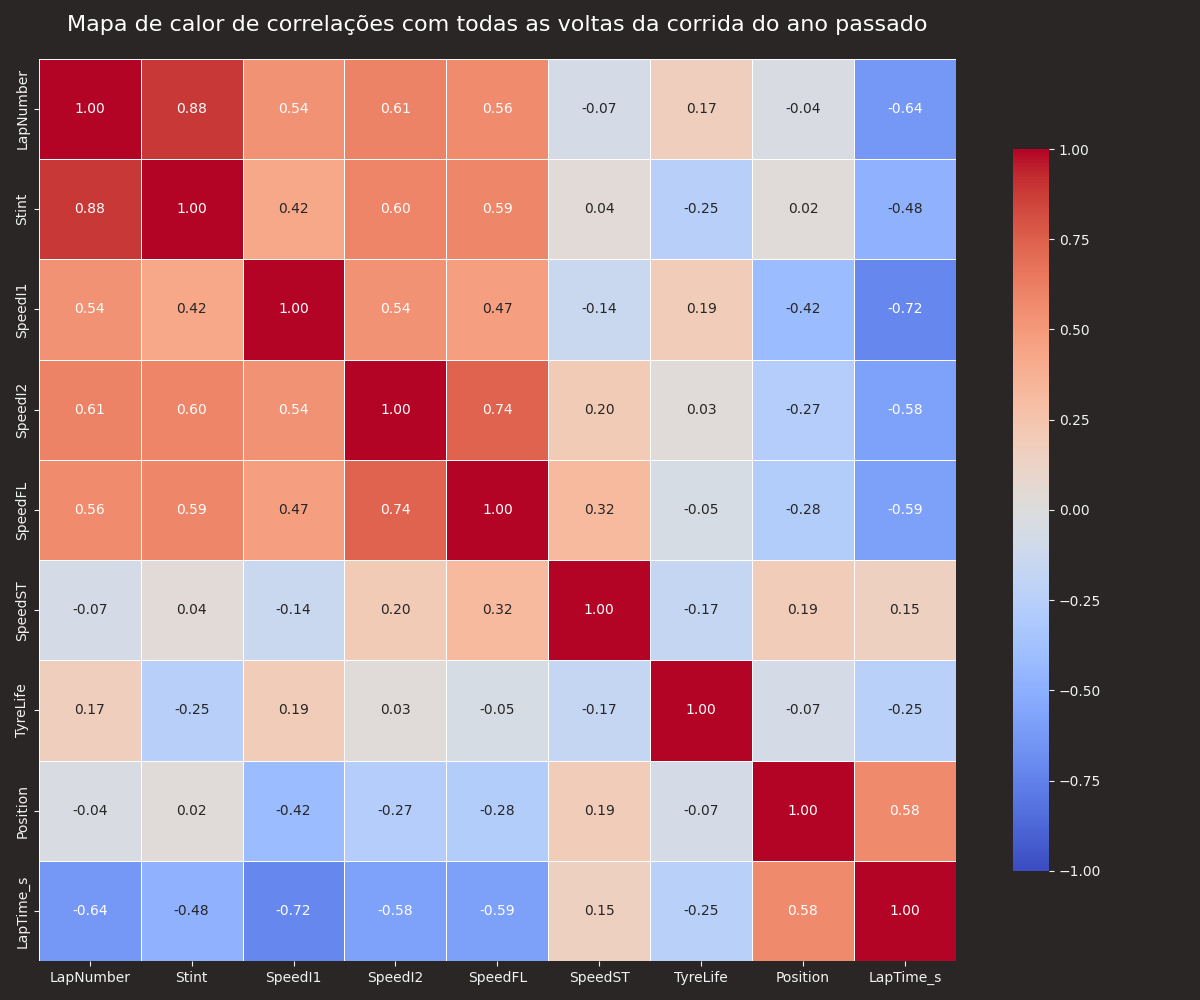


--- Correlations with position ---
LapTime_s     0.58
SpeedI1      -0.42
SpeedFL      -0.28
SpeedI2      -0.27
SpeedST       0.19
TyreLife     -0.07
LapNumber    -0.04
Stint         0.02
Name: Position, dtype: object


In [7]:
plot_position_correlation_heatmap(
    last_year_race_laps,
    title="Mapa de calor de correlações com todas as voltas da corrida do ano passado",
)

A partir dos dados analisados, o tempo de volta possui uma forte correlação com as posições nesse grande prêmio, a maior correlação.

Ademais, a velocidade no primeiro setor intermediário desse circuito é a segunda informação mais importante, atingido um índice considerado moderado (-0.42).

As demais informações também possuem correlações significantes, porém mais baixas com a posição dos pilotos.

### 🕒 Historicamente, quais são as métricas mais importantes para se obter bons tempos de volta nesta pista?

Como tempos de volta são a métrica mais importante para se obter resultados nessa corrida, e é o prinicpal objetivo da maioria da engenharia, vamos checar como podemos atingir tempos de volta menores nesse ciruito. Vamos filtrar apenas voltas de "push", isso é, as voltas em que pilotos não estão indo devagar intencionalmente. A FIA estabelece que nessas voltas, deve haver uma diferença de até 107% com a volta mais rápida.

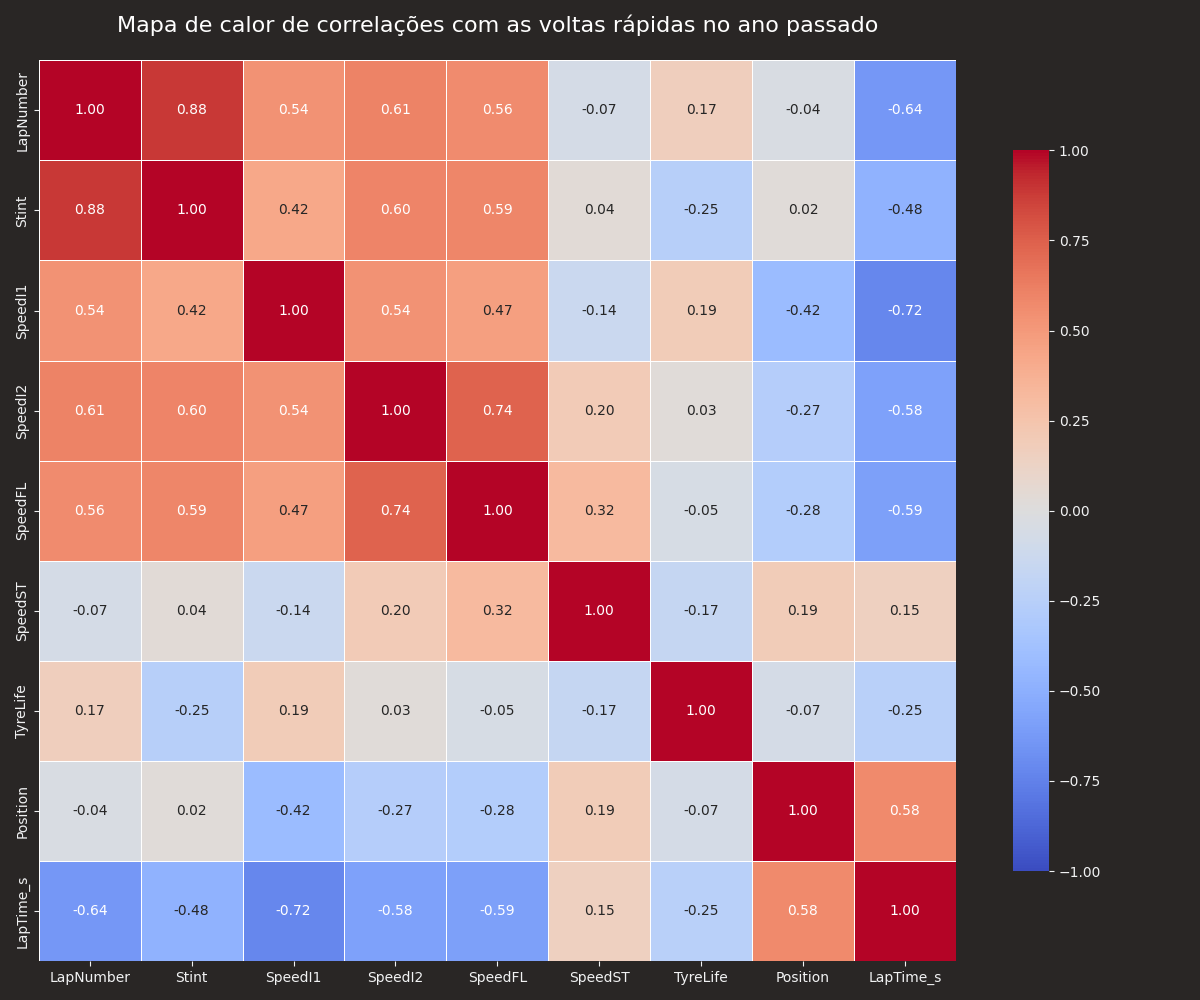


--- Correlations with lap time ---
SpeedI1      -0.72
LapNumber    -0.64
SpeedFL      -0.59
SpeedI2      -0.58
Position      0.58
Stint        -0.48
TyreLife     -0.25
SpeedST       0.15
Name: LapTime_s, dtype: object


In [8]:
plot_laptime_correlation_heatmap(
    last_year_push_laps,
    title="Mapa de calor de correlações com as voltas rápidas no ano passado",
)

A velocidade no primeiro setor intermediário possui a correlação mais forte no que se trata em obter tempos de volta menores (-0.72), enquanto outras métricas de velocidade também se demonstram altamente correlatas, como velocidade ao cruzar a linha de chegada (-0.59) e velocidade no segundo setor intermediário (-0.58).

O stint, isso é, a quantidade de voltas consecutivas com o mesmo conjunto de pneus, também possui uma correlação negativa moderada (0.48). Quanto maior o stint, menor o tempo da volta. Contudo, é importante tomar cuidado com essa interpretação, uma vez que isso é um resultado altamente influenciado pelas estratégias de corrida dos times. Os seus esforços, essencialmente, focam em aumentar essa correlação para obterem melhores tempos de volta.

Ademais, tome nota: a quantidade de voltas não magicamente faz com que o carro se torne mais rápido. Se trata de uma correlação espúria.

### 🚩 Quantos incidentes acontecem nesse circuito?

Por mais que uma correlação de 0.58 demonstre uma relação linear clara, também demonstra que apenas tempos de volta não são o suficiente para determinar o resultado da corrida. Uma proporção substancial de variância não explicada sugere que variáveis exógenas - como a estratégia de corrida - também desempenham um papel crítico no resultado da corrida.

Uma grande parte da estratégia de corridas de F1 gira em torno de pit stops, gerenciamento de pneus, e gerenciamento estratégico de safety cars.

Como safety cars podem bagunçar bastante planejamentos estratégicos, vamos observar quantos incidentes aconteceram nas iterações prévias desse GP.

In [9]:
print(
    f"Houve um total de {len(incidents)} incidentes nos anos recentes desse",
    "GP que resultaram em uma bandeira veremelha, preta ou amarela.",
)

Houve um total de 13 incidentes nos anos recentes desse GP que resultaram em uma bandeira veremelha, preta ou amarela.


In [10]:
print(
    f"Isso significa uma média de {len(incidents) / len(incidents.Year.unique()):.2f}",
    "incidentes por corrida.",
)

Isso significa uma média de 4.33 incidentes por corrida.


In [11]:
min_incidents = incidents.groupby("Year").size().min()
print(
    "Nos anos recentes, a corrida com o menor número de incidentes teve",
    f"{min_incidents} incidentes.",
)

Nos anos recentes, a corrida com o menor número de incidentes teve 3 incidentes.


In [12]:
last_year_incidents = len(incidents[incidents["Year"] == EVENT_YEAR - 1])
print(f"No ano passado, aconteceram {last_year_incidents} desse tipo de incidente.")

No ano passado, aconteceram 5 desse tipo de incidente.


## 💡 Resumo e conclusões

O fator mais importante para atingir boas posições nesse circuito é o tempo de volta, com a maior correlação linear observada.

A segunda métrica mais impactante era a velocidade registrada no primeiro setor intermediário da pista (-0.42), sugerindo que essa seção é particularmente decisiva para performance.

### 🕒 O que está por trás de voltas rápidas?

Observando especificamente voltas "push" (dentro do intervalo de 107%), a análise encontrou que:
- **A velocidade registrada no primeiro setor intermediário** tem a maior correlação linear com voltas mais rápidas (−0.72).
- **A velocidade registrada na linha de chegada e segundo setor intermediário** também são fortemente correlacionadas (−0.59 e −0.58, respectivamente).
- **Duração do stint** apresenta uma correlação moderada (−0.48) — voltas geralmente se tornam mais rápidas à medida que a corrida progride, refletindo o impacto da estratégia dos times e aquecimento dos pneus. Isso é um efeito causado pela estratégia do time e escolhas de gerenciamento de pneus!

### ♟️ Estratégias de corrida

Apesar da forte correlação linear com a posição (0.58), existe uma variância significativa que não pode ser explicada apenas por tempos de volta, sugerindo a importância de variáveis exógenas como a estratégia - pit stops, gerenciamento de pneus e a resposta para safety cars.

Este notebook também computou o histórico de incidentes da pista que resultaram em bandeiras vermelhas, amarelas e pretas. O total foi de **13 incidentes ao todo**, resultando em uma **média de 4.3 por corrida**. O **mínimo** foi de **3** incidentes em uma edição, e no **ano passado, 5 incidentes** foram registrados.